In [32]:
import torch

In [33]:
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor, Lambda

In [34]:
train_set = MNIST(root="data",
                  train=True,
                  download=True,
                  transform=ToTensor(),
                  target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter(0, torch.tensor(y), value=1)))
test_set = MNIST(root="data",
                 train=False,
                 download=True,
                 transform=ToTensor(),
                 target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter(0, torch.tensor(y), value=1)))

In [35]:
from torch.utils.data import DataLoader

In [36]:
train_dataloader = DataLoader(train_set, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_set, batch_size=64, shuffle=True)

In [37]:
from torch import nn

In [38]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.network = nn.Sequential(
        nn.Linear(28*28, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 10),
    )

  def forward(self, x):
    x = self.flatten(x)
    logits = self.network(x)
    return logits

model = NeuralNetwork().to(device)
print(model)


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [39]:
learning_rate, epochs, batch_size = 0.01, 10, 64
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [42]:
from os import pread
def train_loop(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)

  model.train()
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    # Forward pass
    pred = model(X)

    # Loss calculation
    loss = loss_fn(pred, y)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 100 == 0:
      loss, current = loss.item(), batch * batch_size + len(X)
      print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test_loop(dataloader, model, loss_fn):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)

  test_loss, correct = 0, 0
  model.eval()

  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y.argmax(1)).type(torch.float).sum().item()

  test_loss /= num_batches
  correct /= size
  print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")


In [43]:
for e in range(epochs):
    print(f"Epoch {e+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 0.659574  [   64/60000]
loss: 0.524419  [ 6464/60000]
loss: 0.644223  [12864/60000]
loss: 0.400920  [19264/60000]
loss: 0.600571  [25664/60000]
loss: 0.332715  [32064/60000]
loss: 0.201927  [38464/60000]
loss: 0.418996  [44864/60000]
loss: 0.395866  [51264/60000]
loss: 0.407216  [57664/60000]
Test Error: 
 Accuracy: 89.4%, Avg loss: 0.388136 

Epoch 2
-------------------------------
loss: 0.268798  [   64/60000]
loss: 0.566595  [ 6464/60000]
loss: 0.574921  [12864/60000]
loss: 0.244652  [19264/60000]
loss: 0.410592  [25664/60000]
loss: 0.330095  [32064/60000]
loss: 0.401954  [38464/60000]
loss: 0.261978  [44864/60000]
loss: 0.263150  [51264/60000]
loss: 0.228326  [57664/60000]
Test Error: 
 Accuracy: 90.5%, Avg loss: 0.329983 

Epoch 3
-------------------------------
loss: 0.386083  [   64/60000]
loss: 0.318741  [ 6464/60000]
loss: 0.214348  [12864/60000]
loss: 0.311416  [19264/60000]
loss: 0.545665  [25664/60000]
loss: 0.340570  [32064/600

In [45]:
import matplotlib.pyplot as plt

In [69]:
test_features_batch, test_labels_batch = next(iter(test_dataloader))

Text(0.5, 1.0, 'True Label: 8')

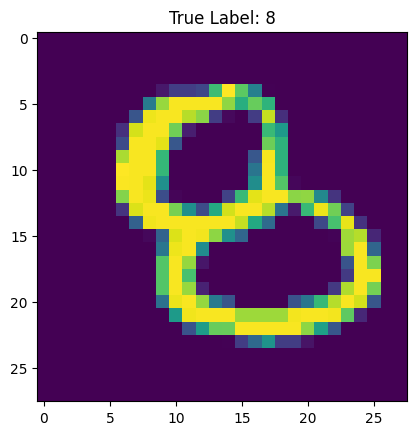

In [70]:
random_idx = torch.randint(0, len(test_features_batch), (1,)).item()

test_feature = test_features_batch[0]
test_label = test_labels_batch[0]

plt.imshow(test_feature.squeeze())
plt.title(f"True Label: {test_label.argmax()}")

In [71]:
test_feature = test_feature.to(device)

In [72]:
prediction = model(test_feature)
output_label = prediction.argmax()
print(f"Predicted Label: {output_label}")

Predicted Label: 8
